# **BUILDING A VIRTUAL CELL IN PYTHON**

This **google colab notebook** serves as an **educational tutorial** on **building a virtual cell model in Python**.

***A Vitual Cell is a computational model designed to predict how gene expression changes in a cell when it is exposed to specific perturbations, such as drugs or environmental changes.***

Machine Learning is utilized in this context because the biological complexity of a cell is too vast to manage with the manual programming.

**Key Reasons Include:**

**1. Handling Scale:** There are approximately 20,000 protein-coding genes and an even greater number of potential perturbations (like drug interactions, knockouts, or environmental changes) that a cell might encounter.

**2. Predictive Power:** By leveraging large **single-cell RNA-seq** datasets, machine learning models can learn the complex relationships between initial cellular states and the specific gene expression changes triggered by perturbations.

**3. Automation:** Manually coding the response of every possible gene to every possible stimulus is impractical; machine learning allows the system to "learn" these patterns from historical data, providing a more scalable approach for **disease understanding** and **drug discovery**.

***A cell has a normal gene-activity pattern. Knock out one gene and that pattern changes. This project trains a small model to guess the new pattern from (1) the normal pattern and (2) a numeric fingerprint
of the knocked-out gene.***

**Google Colab was chosen over a local machine to give every user a zero-setup, GPU-backed runtime that can pull large Virtual Cell Challenge files from GCS and complete training plus interactive prediction without local CUDA, dependency, or memory configuration.**

In [1]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if not IN_COLAB:
    raise RuntimeError(
        "This project is Colab-only. Open this .ipynb in Google Colab:\n"
        "https://colab.research.google.com/"
    )

print("Colab detected. Good.")

Colab detected. Good.


In [2]:
MODE = "DEMO"

MAX_CELLS = 8000
N_HVG = 500
MAX_PERT_GENES = 120
HIDDEN_DIM = 16
MAX_EPOCHS = 40
PATIENCE = 6
BATCH_SIZE = 64
RANDOM_SEED = 23

In [3]:
!pip -q install anndata scanpy gcsfs h5py mygene ipywidgets

from google.colab import output
output.enable_custom_widget_manager()

print("deps ready")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take

In [4]:
from pathlib import Path
ROOT = Path("/content/virtual_cell_colab")
(ROOT / "data" / "ESM2").mkdir(parents=True, exist_ok=True)
(ROOT / "models").mkdir(parents=True, exist_ok=True)
print(ROOT)

/content/virtual_cell_colab


In [5]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

class VirtualCell(nn.Module):
    def __init__(self, expr_dim, emb_dim, hidden_dim):
        super().__init__()
        self.delta_net = nn.Sequential(
            nn.Linear(emb_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, expr_dim),
        )
        nn.init.zeros_(self.delta_net[-1].weight)
        nn.init.zeros_(self.delta_net[-1].bias)

    def forward(self, ctrl_expr, pert_emb):
        return ctrl_expr + self.delta_net(pert_emb)


class PerturbationDataset(Dataset):
    def __init__(self, ctrl_expr, pert_genes, target_expr, gene_to_emb):
        self.ctrl_expr = torch.tensor(ctrl_expr, dtype=torch.float32)
        self.pert_genes = list(pert_genes)
        self.target_expr = torch.tensor(target_expr, dtype=torch.float32)
        self.gene_to_emb = gene_to_emb

    def __len__(self):
        return len(self.pert_genes)

    def __getitem__(self, idx):
        gene = self.pert_genes[idx]
        pert_emb = torch.tensor(self.gene_to_emb[gene], dtype=torch.float32)
        target = self.target_expr[idx]
        ctrl_idx = torch.randint(0, self.ctrl_expr.shape[0], (1,)).item()
        return self.ctrl_expr[ctrl_idx], pert_emb, target


def loss_fn(pred_expr, target_expr, ctrl_expr, l1_weight=0.3, cos_weight=1.0):
    l1 = F.l1_loss(pred_expr, target_expr)
    pred_diff = pred_expr - ctrl_expr
    true_diff = target_expr - ctrl_expr
    cos = 1 - F.cosine_similarity(pred_diff, true_diff, dim=1).mean()
    return l1_weight * l1 + cos_weight * cos


def pearson_diff_corr(pred, target, ctrl):
    pred_diff = pred - ctrl
    target_diff = target - ctrl
    pred_c = pred_diff - pred_diff.mean(dim=1, keepdim=True)
    tgt_c = target_diff - target_diff.mean(dim=1, keepdim=True)
    return F.cosine_similarity(pred_c, tgt_c).mean().item()


def compute_baseline_metrics(val_loader, mean_expr, device):
    baseline_loss = 0.0
    baseline_corr = 0.0
    with torch.no_grad():
        for batch_ctrl, _, batch_tgt in val_loader:
            batch_ctrl = batch_ctrl.to(device)
            batch_tgt = batch_tgt.to(device)
            pred = mean_expr.expand_as(batch_tgt)
            baseline_loss += loss_fn(pred, batch_tgt, batch_ctrl).item() * batch_tgt.size(0)
            baseline_corr += pearson_diff_corr(pred, batch_tgt, batch_ctrl) * batch_tgt.size(0)
    n = len(val_loader.dataset)
    return baseline_loss / n, baseline_corr / n


def get_pseudobulks(adata, perturbation_genes):
    pert_genes, pbs = [], []
    for gene in perturbation_genes:
        mask = adata.obs["target_gene"] == gene
        if mask.sum() == 0:
            continue
        x = adata[mask].X
        x = x.toarray() if hasattr(x, "toarray") else np.asarray(x)
        pert_genes.append(gene)
        pbs.append(x.mean(axis=0))
    return np.array(pert_genes), np.stack(pbs)

print("helpers loaded")

helpers loaded


In [6]:
import scanpy as sc
import anndata as ad

rng = np.random.default_rng(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

def make_demo_adata(n_ctrl=80, n_pert_genes=40, cells_per_pert=12, n_genes=200, emb_dim=32):
    gene_names = [f"G{i:04d}" for i in range(n_genes)]
    pert_names = gene_names[:n_pert_genes]
    gene_to_emb = {g: rng.normal(size=emb_dim).astype(np.float32) for g in gene_names}

    rows, labels = [], []
    base = rng.gamma(2.0, 1.0, size=n_genes)
    for _ in range(n_ctrl):
        rows.append(rng.poisson(base).astype(np.float32))
        labels.append("non-targeting")
    for g in pert_names:
        delta = 0.4 * gene_to_emb[g][:n_genes] if emb_dim >= n_genes else rng.normal(size=n_genes)
        profile = np.clip(base + delta, 0.05, None)
        for _ in range(cells_per_pert):
            rows.append(rng.poisson(profile).astype(np.float32))
            labels.append(g)

    X = np.vstack(rows)
    adata = ad.AnnData(X)
    adata.var_names = gene_names
    adata.obs["target_gene"] = labels
    return adata, gene_to_emb


def load_vcc():
    import gcsfs
    train_path = ROOT / "data" / "adata_Training.h5ad"
    if not train_path.exists():
        print("Downloading training h5ad from GCS (this can take a while)...")
        fs = gcsfs.GCSFileSystem()
        src = "gs://arc-institute-virtual-cell-atlas/virtual-cell-challenge/2025/train/adata_Training.h5ad"
        with fs.open(src) as f:
            adata = sc.read_h5ad(f)
        adata.write_h5ad(train_path)
    else:
        adata = sc.read_h5ad(train_path)

    if adata.n_obs > MAX_CELLS:
        sc.pp.subsample(adata, n_obs=MAX_CELLS, random_state=RANDOM_SEED)

    emb_csv = ROOT / "data" / "ESM2" / "ESM2_emb.csv"
    emb_ids = ROOT / "data" / "ESM2" / "ESM2_genelist.txt"
    cache = ROOT / "data" / "gene_to_emb.pkl"
    if cache.exists():
        gene_to_emb = pd.read_pickle(cache)
    elif emb_csv.exists() and emb_ids.exists():
        import mygene
        emb = pd.read_csv(emb_csv, header=None)
        with open(emb_ids) as f:
            ids = [line.strip() for line in f]
        id_to_emb = {gid: emb.iloc[i].values for i, gid in enumerate(ids)}
        mg = mygene.MyGeneInfo()
        res = mg.querymany(ids, scopes="entrezgene", fields="symbol", species="human")
        gene_to_id = {item["symbol"]: item["query"] for item in res if "symbol" in item}
        gene_to_emb = {g: id_to_emb[gene_to_id[g]] for g in gene_to_id if gene_to_id[g] in id_to_emb}
        pd.to_pickle(gene_to_emb, cache)
    else:
        raise FileNotFoundError(
            "VCC mode needs ESM2 files in /content/virtual_cell_colab/data/ESM2/\n"
            "Upload ESM2_emb.csv and ESM2_genelist.txt, or switch MODE to DEMO."
        )
    return adata, gene_to_emb


if MODE == "DEMO":
    adata, gene_to_emb = make_demo_adata()
else:
    adata, gene_to_emb = load_vcc()

print(adata)
print("embeddings:", len(gene_to_emb))

AnnData object with n_obs × n_vars = 560 × 200
    obs: 'target_gene'
    layers: None (.X)
embeddings: 200


In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

genes = sorted(set(adata.obs["target_gene"]) - {"non-targeting"})
genes = [g for g in genes if g in gene_to_emb]
if len(genes) > MAX_PERT_GENES:
    genes = list(np.random.choice(genes, size=MAX_PERT_GENES, replace=False))

train_n = max(2, int(len(genes) * 0.8))
train_genes = list(np.random.choice(genes, size=train_n, replace=False))
val_genes = sorted(set(genes) - set(train_genes))
print(f"train perts={len(train_genes)}  val perts={len(val_genes)}")

ctrl_idx = adata.obs["target_gene"] == "non-targeting"
train_idx = adata.obs["target_gene"].isin(train_genes)

train_view = adata[train_idx | ctrl_idx].copy()
n_hvg = min(N_HVG, train_view.n_vars)
if train_view.n_vars > n_hvg:
    sc.pp.highly_variable_genes(train_view, n_top_genes=n_hvg)
    hvgs = list(train_view.var_names[train_view.var["highly_variable"]])
else:
    hvgs = list(train_view.var_names)

adata = adata[:, hvgs].copy()
X_ctrl = adata[ctrl_idx].X
X_ctrl = X_ctrl.toarray() if hasattr(X_ctrl, "toarray") else np.asarray(X_ctrl)
mean_ctrl_np = X_ctrl.mean(axis=0, keepdims=True)

pert_train, y_train = get_pseudobulks(adata, train_genes)
pert_val, y_val = get_pseudobulks(adata, val_genes)
print(y_train.shape, y_val.shape)

train perts=32  val perts=8
(32, 200) (8, 200)


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_ds = PerturbationDataset(mean_ctrl_np, pert_train, y_train, gene_to_emb)
val_ds = PerturbationDataset(mean_ctrl_np, pert_val, y_val, gene_to_emb)
train_loader = DataLoader(train_ds, batch_size=min(BATCH_SIZE, len(train_ds)), shuffle=True)
val_loader = DataLoader(val_ds, batch_size=min(BATCH_SIZE, len(val_ds)), shuffle=False)

emb_dim = len(next(iter(gene_to_emb.values())))
model_config = {"expr_dim": y_train.shape[1], "emb_dim": emb_dim, "hidden_dim": HIDDEN_DIM}
model = VirtualCell(**model_config).to(device)

mean_expr = torch.tensor(y_train.mean(axis=0), dtype=torch.float32, device=device)
mean_ctrl_t = torch.tensor(mean_ctrl_np, dtype=torch.float32, device=device)
with torch.no_grad():
    model.delta_net[-1].bias.copy_((mean_expr - mean_ctrl_t).squeeze(0))

opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)

bl, bc = compute_baseline_metrics(val_loader, mean_expr, device)
print(f"baseline loss={bl:.4f}  baseline pearson-delta={bc:.4f}")

best = float("inf")
wait = 0
ckpt = ROOT / "models" / "virtual_cell_colab.pth"
history = []

for epoch in range(MAX_EPOCHS):
    model.train()
    tr = 0.0
    for c, e, t in train_loader:
        c, e, t = c.to(device), e.to(device), t.to(device)
        opt.zero_grad()
        pred = model(c, e)
        loss = loss_fn(pred, t, c)
        loss.backward()
        opt.step()
        tr += loss.item() * c.size(0)
    tr /= len(train_ds)

    model.eval()
    vl = vc = 0.0
    with torch.no_grad():
        for c, e, t in val_loader:
            c, e, t = c.to(device), e.to(device), t.to(device)
            pred = model(c, e)
            vl += loss_fn(pred, t, c).item() * c.size(0)
            vc += pearson_diff_corr(pred, t, c) * c.size(0)
    vl /= len(val_ds)
    vc /= len(val_ds)
    sched.step(vl)
    history.append((tr, vl, vc))
    print(f"epoch {epoch+1:03d}  train {tr:.4f}  val {vl:.4f}  corr {vc:.4f}")

    if vl < best:
        best, wait = vl, 0
        torch.save({
            "model_config": model_config,
            "model_state_dict": model.state_dict(),
            "highly_variable_genes": hvgs,
        }, ckpt)
    else:
        wait += 1
        if wait >= PATIENCE:
            print("early stop")
            break

print("saved", ckpt)

device: cuda
baseline loss=1.0045  baseline pearson-delta=0.2116
epoch 001  train 0.9127  val 1.0044  corr 0.2117
epoch 002  train 0.9091  val 1.0043  corr 0.2118
epoch 003  train 0.9055  val 1.0042  corr 0.2119
epoch 004  train 0.9019  val 1.0042  corr 0.2119
epoch 005  train 0.8982  val 1.0042  corr 0.2120
epoch 006  train 0.8944  val 1.0041  corr 0.2120
epoch 007  train 0.8906  val 1.0041  corr 0.2121
epoch 008  train 0.8867  val 1.0041  corr 0.2121
epoch 009  train 0.8828  val 1.0041  corr 0.2121
epoch 010  train 0.8788  val 1.0041  corr 0.2122
epoch 011  train 0.8748  val 1.0040  corr 0.2122
epoch 012  train 0.8707  val 1.0040  corr 0.2122
epoch 013  train 0.8686  val 1.0040  corr 0.2122
epoch 014  train 0.8665  val 1.0041  corr 0.2122
epoch 015  train 0.8644  val 1.0041  corr 0.2122
epoch 016  train 0.8622  val 1.0041  corr 0.2122
epoch 017  train 0.8612  val 1.0041  corr 0.2122
epoch 018  train 0.8601  val 1.0041  corr 0.2122
early stop
saved /content/virtual_cell_colab/models/v

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets

ckpt_obj = torch.load(ROOT / "models" / "virtual_cell_colab.pth", map_location=device)
model = VirtualCell(**ckpt_obj["model_config"]).to(device)
model.load_state_dict(ckpt_obj["model_state_dict"])
model.eval()

ctrl = torch.tensor(mean_ctrl_np, dtype=torch.float32, device=device)
gene_names = hvgs
choices = sorted([g for g in gene_to_emb if g in set(pert_train) | set(pert_val)])

def predict_gene(gene):
    emb = torch.tensor(gene_to_emb[gene], dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        pred = model(ctrl, emb).cpu().numpy().ravel()
    base = mean_ctrl_np.ravel()
    delta = pred - base
    top = np.argsort(np.abs(delta))[::-1][:20]
    df = pd.DataFrame({
        "gene": [gene_names[i] for i in top],
        "control": base[top],
        "predicted": pred[top],
        "delta": delta[top],
    })
    display(df)
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.bar(range(len(top)), delta[top])
    ax.set_xticks(range(len(top)), [gene_names[i] for i in top], rotation=75, ha="right")
    ax.set_title(f"predicted Δexpression after {gene} knockdown")
    ax.set_ylabel("delta")
    plt.tight_layout()
    plt.show()

In [14]:
gene_interact_widget = widgets.interact(predict_gene, gene=widgets.Dropdown(options=choices, description="perturb"))

interactive(children=(Dropdown(description='perturb', options=('G0000', 'G0001', 'G0002', 'G0003', 'G0004', 'G…

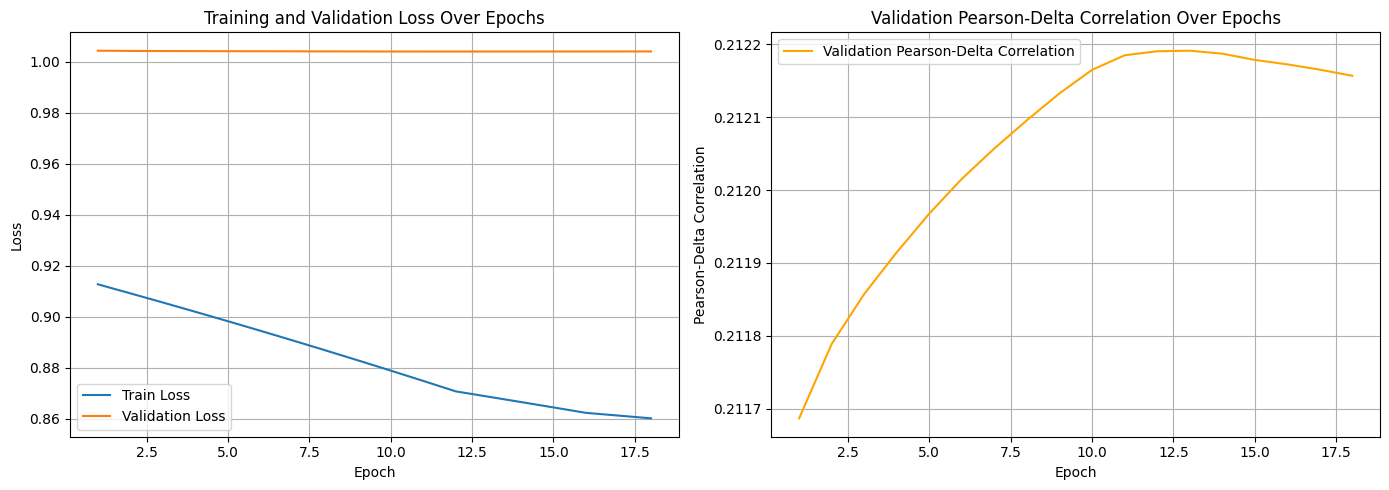

In [15]:
import matplotlib.pyplot as plt

tr_loss = [h[0] for h in history]
val_loss = [h[1] for h in history]
val_corr = [h[2] for h in history]

epochs = range(1, len(history) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, tr_loss, label='Train Loss')
axes[0].plot(epochs, val_loss, label='Validation Loss')
axes[0].set_title('Training and Validation Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, val_corr, label='Validation Pearson-Delta Correlation', color='orange')
axes[1].set_title('Validation Pearson-Delta Correlation Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Pearson-Delta Correlation')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

def jaccard_similarity_sets(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union != 0 else 0

def compute_all_metrics(predictions, targets, controls):
    current_device = predictions.device

    loss = loss_fn(predictions, targets, controls).item()

    pearson_delta = pearson_diff_corr(predictions, targets, controls)

    pred_delta_cpu = (predictions - controls).cpu()
    true_delta_cpu = (targets - controls).cpu()
    mae_delta = torch.abs(pred_delta_cpu - true_delta_cpu).mean().item()

    total_jaccard = 0
    num_perturbations = predictions.shape[0]

    for i in range(num_perturbations):
        current_pred_delta = pred_delta_cpu[i].numpy()
        current_true_delta = true_delta_cpu[i].numpy()

        top_20_pred_idx = np.argsort(np.abs(current_pred_delta))[::-1][:20]
        top_20_true_idx = np.argsort(np.abs(current_true_delta))[::-1][:20]

        set_pred = set(top_20_pred_idx)
        set_true = set(top_20_true_idx)

        total_jaccard += jaccard_similarity_sets(set_pred, set_true)

    avg_jaccard = total_jaccard / num_perturbations

    return {
        "Loss": loss,
        "Pearson-Delta": pearson_delta,
        "MAE Delta": mae_delta,
        "Top-20 Jaccard": avg_jaccard
    }

print("Evaluating ESM2 Model...")
model.eval()

esm2_predictions_list = []
esm2_targets_list = []
esm2_controls_list = []

with torch.no_grad():
    for batch_ctrl, batch_emb, batch_tgt in val_loader:
        batch_ctrl = batch_ctrl.to(device)
        batch_emb = batch_emb.to(device)
        batch_tgt = batch_tgt.to(device)

        pred_expr = model(batch_ctrl, batch_emb)

        esm2_predictions_list.append(pred_expr)
        esm2_targets_list.append(batch_tgt)
        esm2_controls_list.append(batch_ctrl)

esm2_predictions_tensor = torch.cat(esm2_predictions_list, dim=0)
esm2_targets_tensor = torch.cat(esm2_targets_list, dim=0)
esm2_controls_tensor = torch.cat(esm2_controls_list, dim=0)

esm2_metrics = compute_all_metrics(esm2_predictions_tensor, esm2_targets_tensor, esm2_controls_tensor)

print("Evaluating Mean Baseline...")
baseline_predictions_list = []
baseline_targets_list = []
baseline_controls_list = []

mean_expr_device = mean_expr.to(device)

with torch.no_grad():
    for batch_ctrl, _, batch_tgt in val_loader:
        batch_ctrl = batch_ctrl.to(device)
        batch_tgt = batch_tgt.to(device)

        pred_baseline = mean_expr_device.expand_as(batch_tgt)

        baseline_predictions_list.append(pred_baseline)
        baseline_targets_list.append(batch_tgt)
        baseline_controls_list.append(batch_ctrl)

baseline_predictions_tensor = torch.cat(baseline_predictions_list, dim=0)
baseline_targets_tensor = torch.cat(baseline_targets_list, dim=0)
baseline_controls_tensor = torch.cat(baseline_controls_list, dim=0)

baseline_metrics = compute_all_metrics(baseline_predictions_tensor, baseline_targets_tensor, baseline_controls_tensor)

results_df = pd.DataFrame([esm2_metrics, baseline_metrics], index=["ESM2 Model", "Mean Baseline"])
display(results_df.round(4))

Evaluating ESM2 Model...
Evaluating Mean Baseline...


,Loss,Pearson-Delta,MAE Delta,Top-20 Jaccard
ESM2 Model,1.0040,0.2122,0.8538,0.1097
Mean Baseline,1.0045,0.2116,0.8559,0.1051


In [17]:
print("Generating random Gaussian embeddings...")
emb_dim_esm2 = emb_dim
gene_to_emb_random = {}
for gene in gene_names:
    gene_to_emb_random[gene] = rng.normal(size=emb_dim_esm2).astype(np.float32)

random_train_ds = PerturbationDataset(mean_ctrl_np, pert_train, y_train, gene_to_emb_random)
random_val_ds = PerturbationDataset(mean_ctrl_np, pert_val, y_val, gene_to_emb_random)
random_train_loader = DataLoader(random_train_ds, batch_size=min(BATCH_SIZE, len(random_train_ds)), shuffle=True)
random_val_loader = DataLoader(random_val_ds, batch_size=min(BATCH_SIZE, len(random_val_ds)), shuffle=False)

print("Initializing new model for random embeddings...")
random_model_config = {"expr_dim": y_train.shape[1], "emb_dim": emb_dim_esm2, "hidden_dim": HIDDEN_DIM}
random_model = VirtualCell(**random_model_config).to(device)

with torch.no_grad():
    random_model.delta_net[-1].bias.copy_((mean_expr - mean_ctrl_t).squeeze(0))

random_opt = torch.optim.AdamW(random_model.parameters(), lr=1e-3, weight_decay=1e-5)
random_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(random_opt, mode="min", factor=0.5, patience=3)

random_history = []
random_best_val_loss = float("inf")
random_wait = 0
random_ckpt = ROOT / "models" / "virtual_cell_colab_random_emb.pth"

print("Starting training with random embeddings...")
for epoch in range(MAX_EPOCHS):
    random_model.train()
    tr = 0.0
    for c, e, t in random_train_loader:
        c, e, t = c.to(device), e.to(device), t.to(device)
        random_opt.zero_grad()
        pred = random_model(c, e)
        loss = loss_fn(pred, t, c)
        loss.backward()
        random_opt.step()
        tr += loss.item() * c.size(0)
    tr /= len(random_train_ds)

    random_model.eval()
    vl = vc = 0.0
    with torch.no_grad():
        for c, e, t in random_val_loader:
            c, e, t = c.to(device), e.to(device), t.to(device)
            pred = random_model(c, e)
            vl += loss_fn(pred, t, c).item() * c.size(0)
            vc += pearson_diff_corr(pred, t, c) * c.size(0)
    vl /= len(random_val_ds)
    vc /= len(random_val_ds)
    random_sched.step(vl)
    random_history.append((tr, vl, vc))
    print(f"epoch {epoch+1:03d}  train {tr:.4f}  val {vl:.4f}  corr {vc:.4f}")

    if vl < random_best_val_loss:
        random_best_val_loss, random_wait = vl, 0
        torch.save({
            "model_config": random_model_config,
            "model_state_dict": random_model.state_dict(),
            "highly_variable_genes": hvgs,
        }, random_ckpt)
    else:
        random_wait += 1
        if random_wait >= PATIENCE:
            print("early stop")
            break

print("saved random embedding model to", random_ckpt)

Generating random Gaussian embeddings...
Initializing new model for random embeddings...
Starting training with random embeddings...
epoch 001  train 0.9127  val 1.0043  corr 0.2118
epoch 002  train 0.9092  val 1.0041  corr 0.2121
epoch 003  train 0.9056  val 1.0038  corr 0.2123
epoch 004  train 0.9020  val 1.0036  corr 0.2126
epoch 005  train 0.8983  val 1.0034  corr 0.2128
epoch 006  train 0.8946  val 1.0032  corr 0.2130
epoch 007  train 0.8908  val 1.0031  corr 0.2133
epoch 008  train 0.8869  val 1.0029  corr 0.2135
epoch 009  train 0.8830  val 1.0027  corr 0.2137
epoch 010  train 0.8790  val 1.0026  corr 0.2138
epoch 011  train 0.8750  val 1.0024  corr 0.2140
epoch 012  train 0.8709  val 1.0023  corr 0.2142
epoch 013  train 0.8667  val 1.0021  corr 0.2143
epoch 014  train 0.8624  val 1.0020  corr 0.2145
epoch 015  train 0.8581  val 1.0019  corr 0.2146
epoch 016  train 0.8537  val 1.0018  corr 0.2147
epoch 017  train 0.8493  val 1.0017  corr 0.2148
epoch 018  train 0.8448  val 1.001

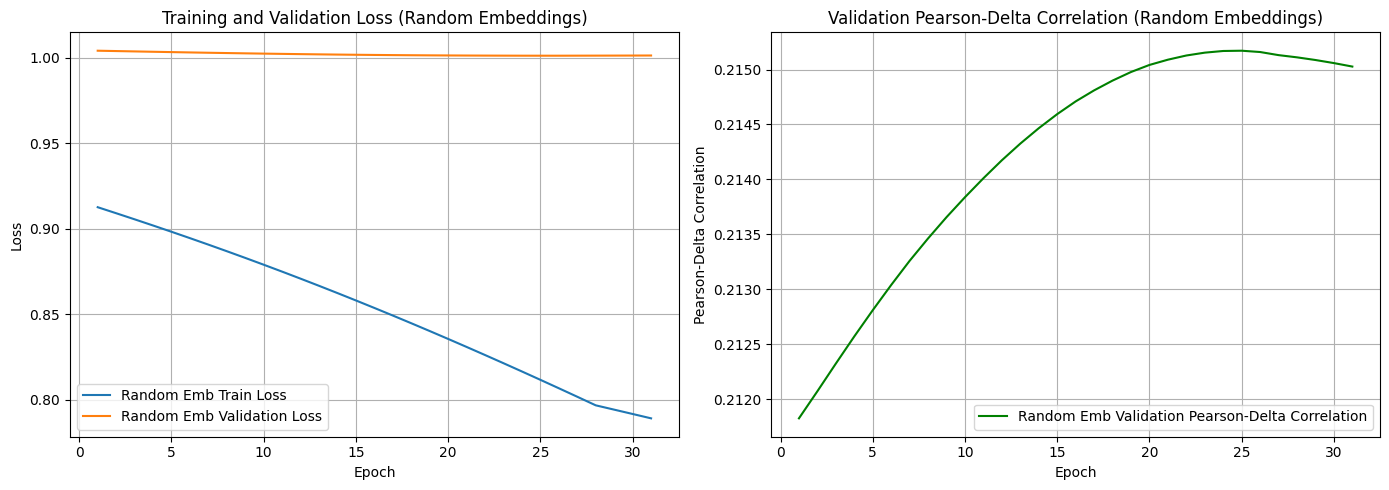

In [18]:
import matplotlib.pyplot as plt

tr_loss_random = [h[0] for h in random_history]
val_loss_random = [h[1] for h in random_history]
val_corr_random = [h[2] for h in random_history]

epochs_random = range(1, len(random_history) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_random, tr_loss_random, label='Random Emb Train Loss')
axes[0].plot(epochs_random, val_loss_random, label='Random Emb Validation Loss')
axes[0].set_title('Training and Validation Loss (Random Embeddings)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_random, val_corr_random, label='Random Emb Validation Pearson-Delta Correlation', color='green')
axes[1].set_title('Validation Pearson-Delta Correlation (Random Embeddings)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Pearson-Delta Correlation')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [19]:
random_model_ckpt_obj = torch.load(random_ckpt, map_location=device)
random_model_eval = VirtualCell(**random_model_ckpt_obj["model_config"]).to(device)
random_model_eval.load_state_dict(random_model_ckpt_obj["model_state_dict"])
random_model_eval.eval()

print("Evaluating Random Embeddings Model...")
random_predictions_list = []
random_targets_list = []
random_controls_list = []

with torch.no_grad():
    for batch_ctrl, batch_emb, batch_tgt in random_val_loader:
        batch_ctrl = batch_ctrl.to(device)
        batch_emb = batch_emb.to(device)
        batch_tgt = batch_tgt.to(device)

        pred_expr = random_model_eval(batch_ctrl, batch_emb)

        random_predictions_list.append(pred_expr)
        random_targets_list.append(batch_tgt)
        random_controls_list.append(batch_ctrl)

random_predictions_tensor = torch.cat(random_predictions_list, dim=0)
random_targets_tensor = torch.cat(random_targets_list, dim=0)
random_controls_tensor = torch.cat(random_controls_list, dim=0)

random_metrics = compute_all_metrics(random_predictions_tensor, random_targets_tensor, random_controls_tensor)

all_results_df = pd.DataFrame([
    esm2_metrics,
    random_metrics,
    baseline_metrics
], index=["ESM2 Model", "Random Embeddings Model", "Mean Baseline"])

display(all_results_df.round(4))


Evaluating Random Embeddings Model...


,Loss,Pearson-Delta,MAE Delta,Top-20 Jaccard
ESM2 Model,1.0040,0.2122,0.8538,0.1097
Random Embeddings Model,1.0013,0.2152,0.8496,0.1017
Mean Baseline,1.0045,0.2116,0.8559,0.1051


Plotting scatter plots for ESM2 Model...


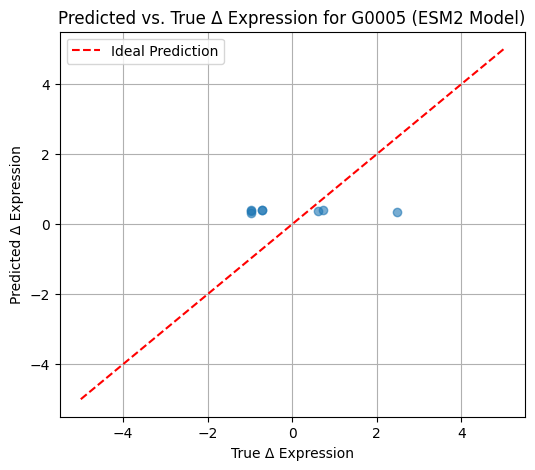

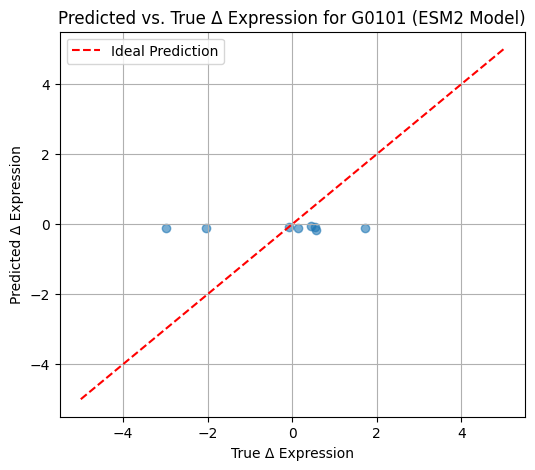

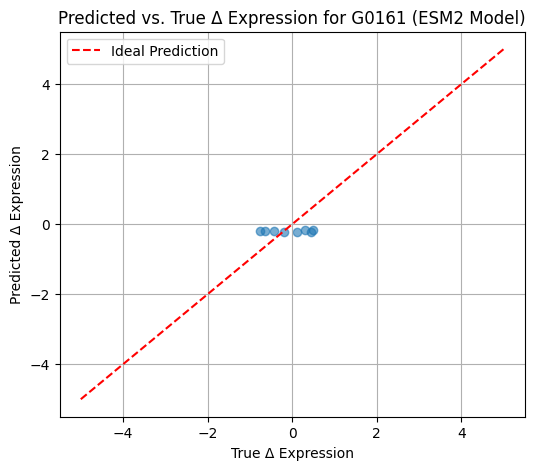

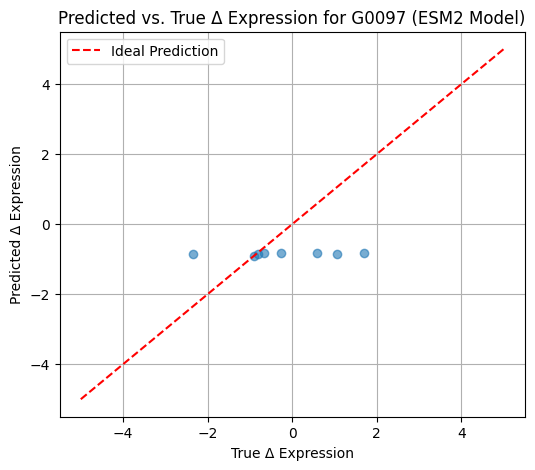

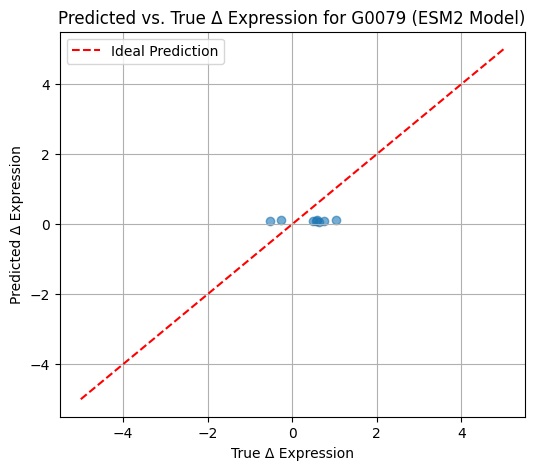

Plotting scatter plots for Random Embeddings Model...


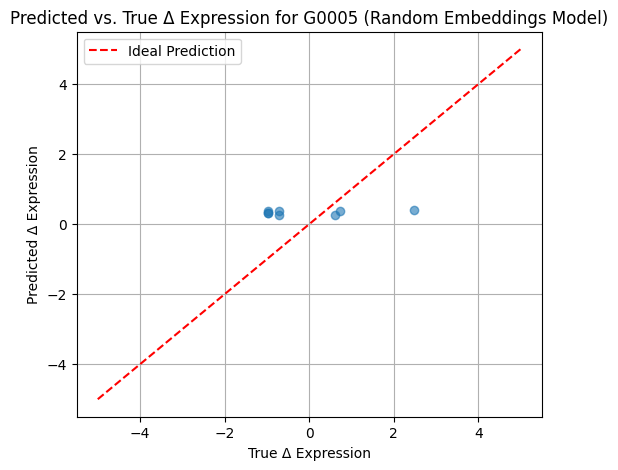

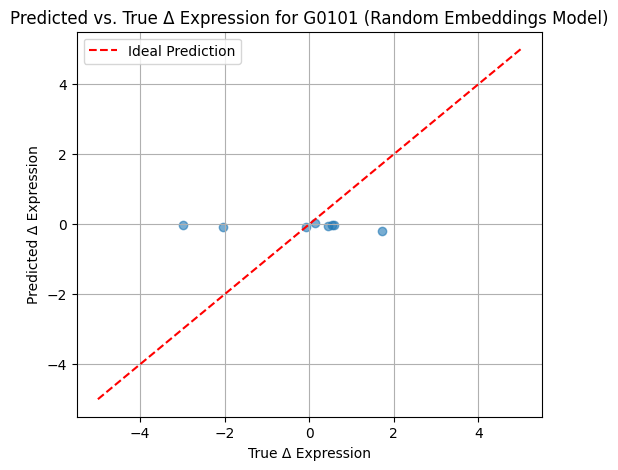

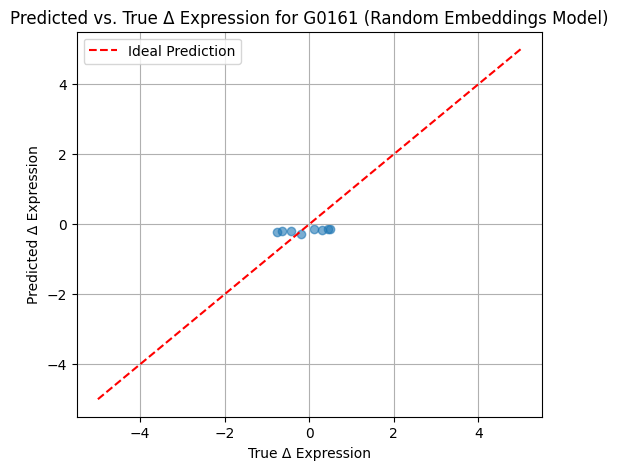

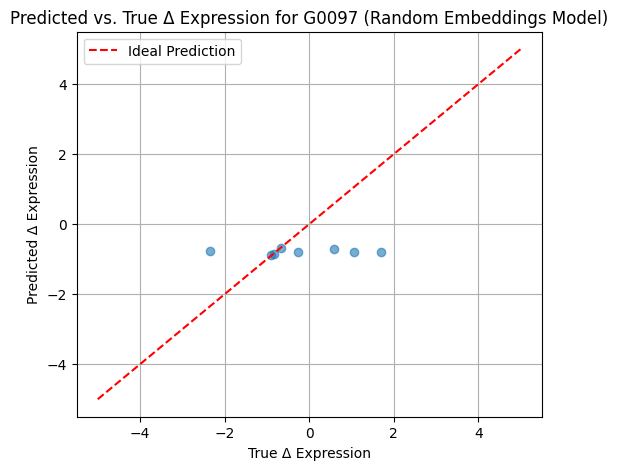

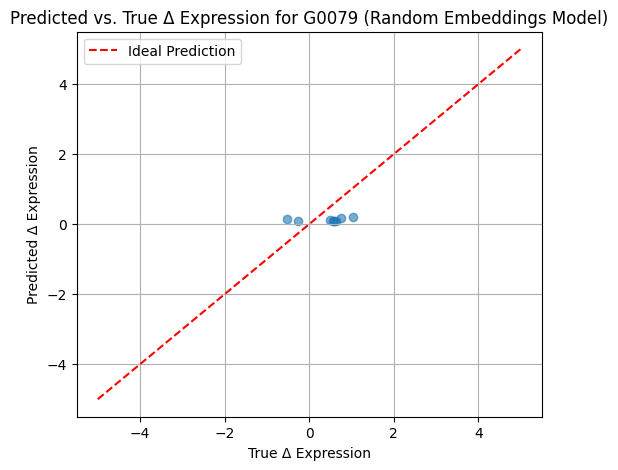

Plotting scatter plots for Mean Baseline...


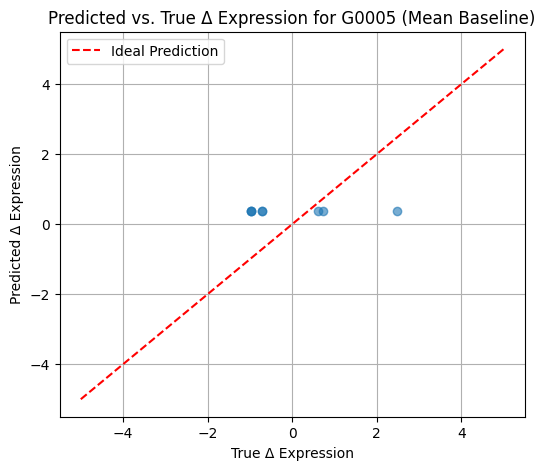

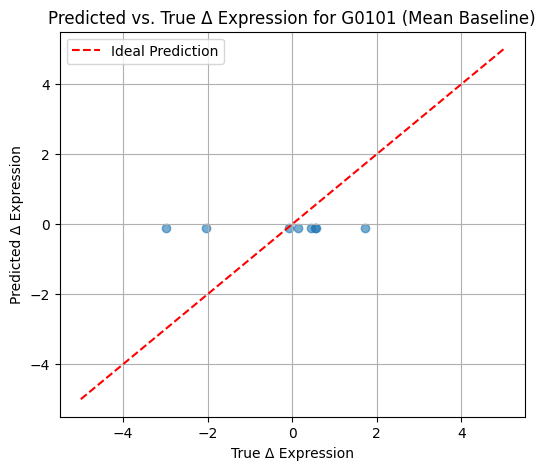

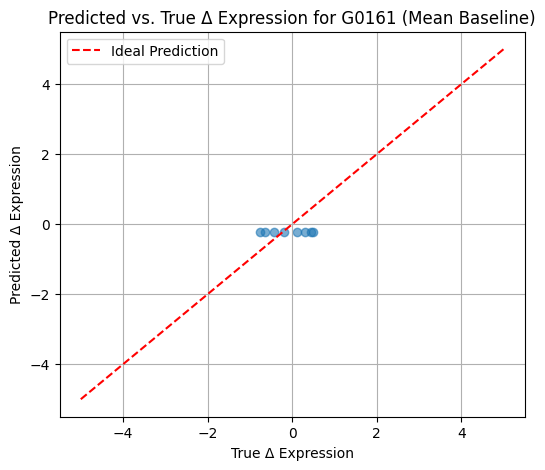

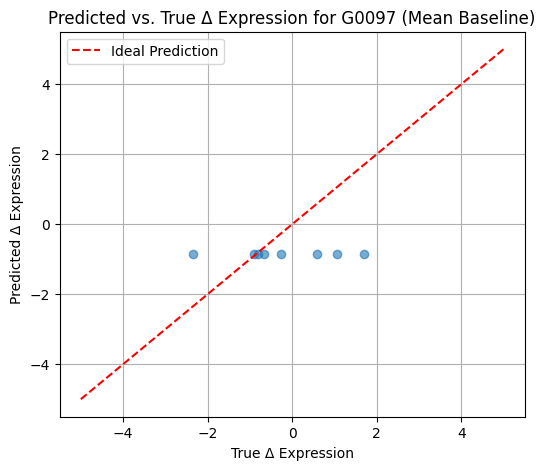

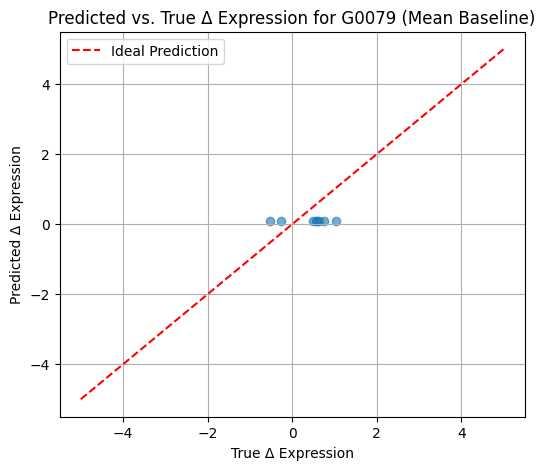

In [20]:
def plot_scatter_deltas(model_name, predictions_tensor, targets_tensor, controls_tensor, gene_idx=None, n_genes=5):
    predictions_cpu = predictions_tensor.cpu().numpy()
    targets_cpu = targets_tensor.cpu().numpy()
    controls_cpu = controls_tensor.cpu().numpy()

    pred_deltas = predictions_cpu - controls_cpu
    true_deltas = targets_cpu - controls_cpu

    if gene_idx is None:
        available_genes_count = len(hvgs)
        if available_genes_count < n_genes:
            n_genes = available_genes_count

        selected_gene_indices = np.random.choice(available_genes_count, n_genes, replace=False)
    else:
        selected_gene_indices = gene_idx

    for g_idx in selected_gene_indices:
        gene_name = hvgs[g_idx]
        plt.figure(figsize=(6, 5))
        plt.scatter(true_deltas[:, g_idx], pred_deltas[:, g_idx], alpha=0.6)
        plt.title(f'Predicted vs. True Δ Expression for {gene_name} ({model_name})')
        plt.xlabel('True Δ Expression')
        plt.ylabel('Predicted Δ Expression')
        plt.plot([-5, 5], [-5, 5], 'r--', label='Ideal Prediction')
        plt.grid(True)
        plt.legend()
        plt.show()

plot_genes = np.random.choice(len(hvgs), min(5, len(hvgs)), replace=False)

print("Plotting scatter plots for ESM2 Model...")
plot_scatter_deltas("ESM2 Model", esm2_predictions_tensor, esm2_targets_tensor, esm2_controls_tensor, gene_idx=plot_genes)

print("Plotting scatter plots for Random Embeddings Model...")
plot_scatter_deltas("Random Embeddings Model", random_predictions_tensor, random_targets_tensor, random_controls_tensor, gene_idx=plot_genes)

print("Plotting scatter plots for Mean Baseline...")
plot_scatter_deltas("Mean Baseline", baseline_predictions_tensor, baseline_targets_tensor, baseline_controls_tensor, gene_idx=plot_genes)


Plotting scatter plots for Random Embeddings Model...


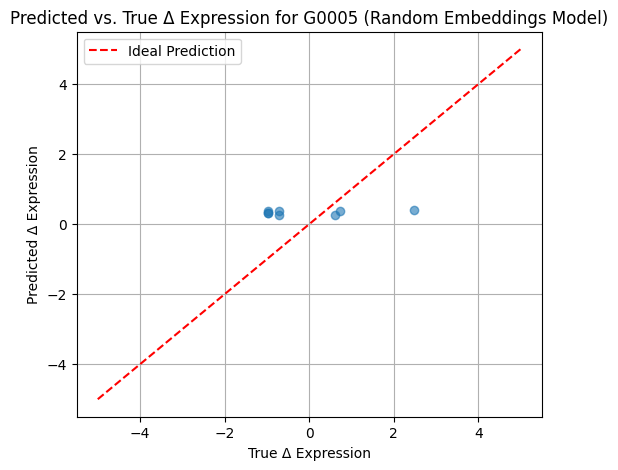

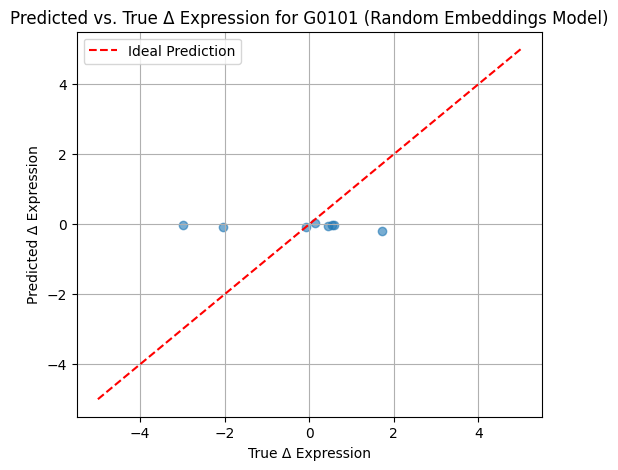

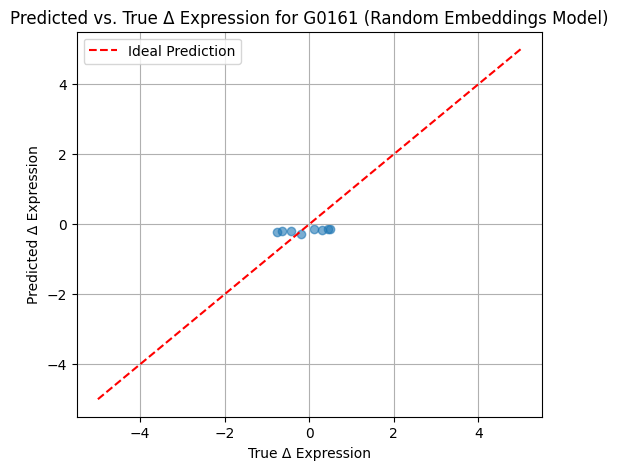

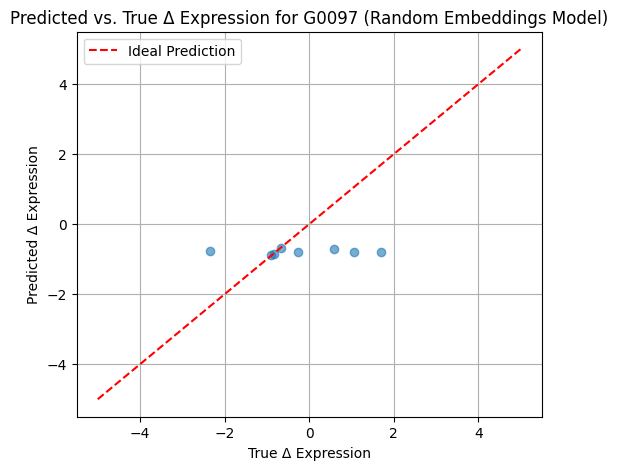

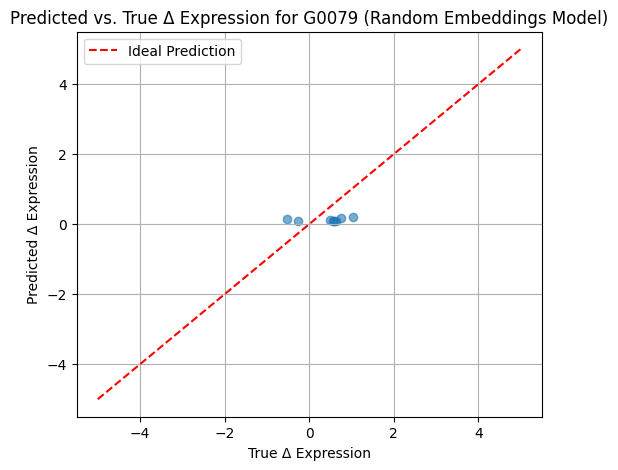

In [21]:
print("Plotting scatter plots for Random Embeddings Model...")
plot_scatter_deltas("Random Embeddings Model", random_predictions_tensor, random_targets_tensor, random_controls_tensor, gene_idx=plot_genes)

Plotting scatter plots for Mean Baseline...


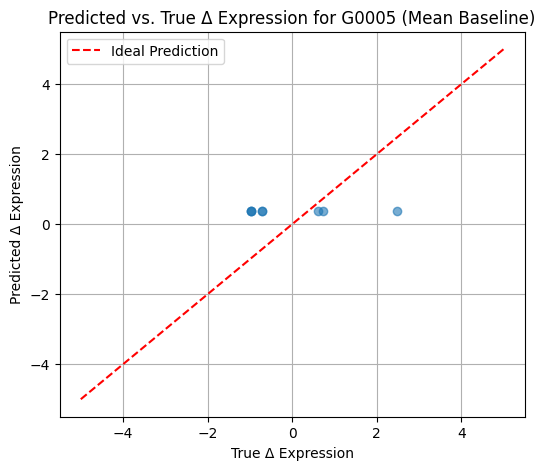

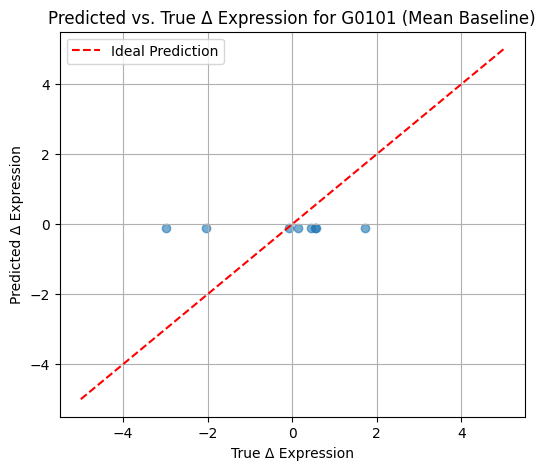

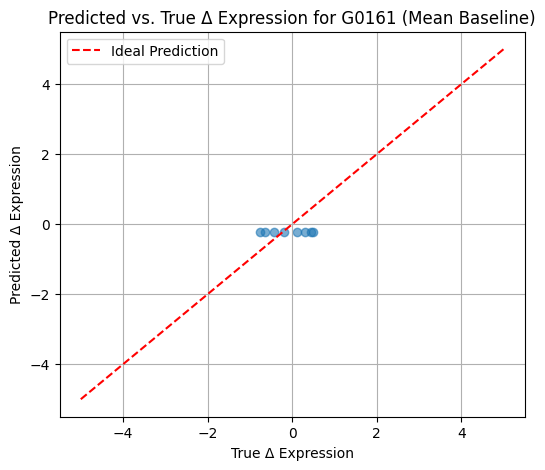

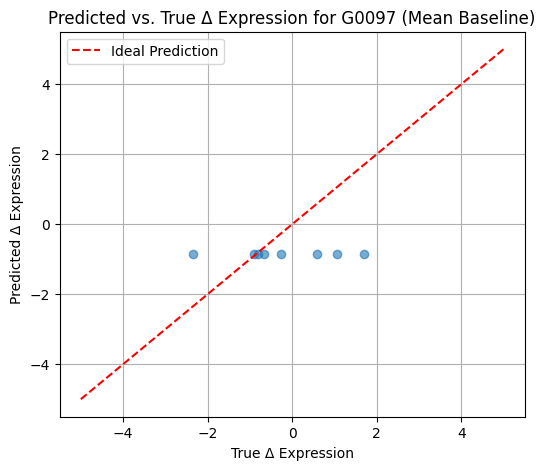

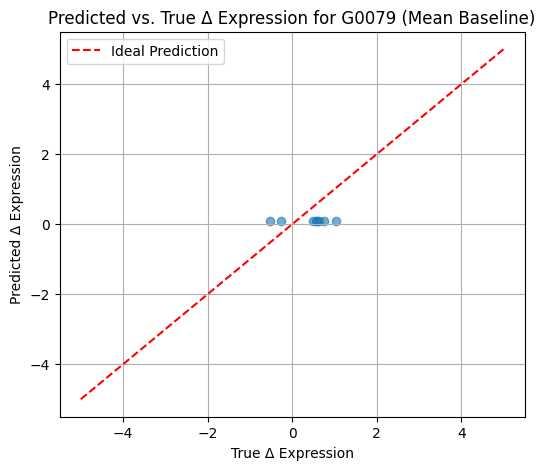

In [22]:
print("Plotting scatter plots for Mean Baseline...")
plot_scatter_deltas("Mean Baseline", baseline_predictions_tensor, baseline_targets_tensor, baseline_controls_tensor, gene_idx=plot_genes)

In [23]:
class LinearDeltaModel(nn.Module):
    def __init__(self, expr_dim, emb_dim):
        super().__init__()
        self.linear = nn.Linear(emb_dim, expr_dim)
        nn.init.zeros_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, ctrl_expr, pert_emb):
        delta_pred = self.linear(pert_emb)
        return ctrl_expr + delta_pred


print("Initializing and training Linear Delta Baseline model...")

linear_model = LinearDeltaModel(expr_dim=y_train.shape[1], emb_dim=emb_dim).to(device)

true_train_deltas = torch.tensor(y_train - mean_ctrl_np, dtype=torch.float32)
mean_train_delta = true_train_deltas.mean(dim=0)
with torch.no_grad():
    linear_model.linear.bias.copy_(mean_train_delta)

linear_opt = torch.optim.AdamW(linear_model.parameters(), lr=1e-3, weight_decay=1e-5)
linear_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(linear_opt, mode="min", factor=0.5, patience=3)

linear_history = []
linear_best_val_loss = float("inf")
linear_wait = 0
linear_ckpt = ROOT / "models" / "linear_delta_baseline.pth"

for epoch in range(MAX_EPOCHS):
    linear_model.train()
    tr = 0.0
    for c, e, t in train_loader:
        c, e, t = c.to(device), e.to(device), t.to(device)
        linear_opt.zero_grad()
        pred = linear_model(c, e)
        loss = loss_fn(pred, t, c)
        loss.backward()
        linear_opt.step()
        tr += loss.item() * c.size(0)
    tr /= len(train_ds)

    linear_model.eval()
    vl = vc = 0.0
    with torch.no_grad():
        for c, e, t in val_loader:
            c, e, t = c.to(device), e.to(device), t.to(device)
            pred = linear_model(c, e)
            vl += loss_fn(pred, t, c).item() * c.size(0)
            vc += pearson_diff_corr(pred, t, c) * c.size(0)
    vl /= len(val_ds)
    vc /= len(val_ds)
    linear_sched.step(vl)
    linear_history.append((tr, vl, vc))
    print(f"epoch {epoch+1:03d}  train {tr:.4f}  val {vl:.4f}  corr {vc:.4f}")

    if vl < linear_best_val_loss:
        linear_best_val_loss, linear_wait = vl, 0
        torch.save({
            "model_config": {"expr_dim": y_train.shape[1], "emb_dim": emb_dim},
            "model_state_dict": linear_model.state_dict(),
            "highly_variable_genes": hvgs,
        }, linear_ckpt)
    else:
        linear_wait += 1
        if linear_wait >= PATIENCE:
            print("early stop")
            break

print("saved linear delta baseline model to", linear_ckpt)

print("\nEvaluating Linear Delta Model...")
linear_model_eval = LinearDeltaModel(expr_dim=y_train.shape[1], emb_dim=emb_dim).to(device)
linear_model_eval.load_state_dict(torch.load(linear_ckpt, map_location=device)["model_state_dict"])
linear_model_eval.eval()

linear_predictions_list = []
linear_targets_list = []
linear_controls_list = []

with torch.no_grad():
    for batch_ctrl, batch_emb, batch_tgt in val_loader:
        batch_ctrl = batch_ctrl.to(device)
        batch_emb = batch_emb.to(device)
        batch_tgt = batch_tgt.to(device)

        pred_expr = linear_model_eval(batch_ctrl, batch_emb)

        linear_predictions_list.append(pred_expr)
        linear_targets_list.append(batch_tgt)
        linear_controls_list.append(batch_ctrl)

linear_predictions_tensor = torch.cat(linear_predictions_list, dim=0)
linear_targets_tensor = torch.cat(linear_targets_list, dim=0)
linear_controls_tensor = torch.cat(linear_controls_list, dim=0)

linear_metrics = compute_all_metrics(linear_predictions_tensor, linear_targets_tensor, linear_controls_tensor)

all_results_df = pd.DataFrame([
    esm2_metrics,
    random_metrics,
    baseline_metrics,
    linear_metrics
], index=["ESM2 Model", "Random Embeddings Model", "Mean Baseline", "Linear Delta Baseline"])

display(all_results_df.round(4))


Initializing and training Linear Delta Baseline model...
epoch 001  train 0.9127  val 1.0047  corr 0.2114
epoch 002  train 0.9005  val 1.0049  corr 0.2111
epoch 003  train 0.8884  val 1.0053  corr 0.2108
epoch 004  train 0.8764  val 1.0057  corr 0.2105
epoch 005  train 0.8646  val 1.0061  corr 0.2101
epoch 006  train 0.8529  val 1.0063  corr 0.2099
epoch 007  train 0.8472  val 1.0065  corr 0.2098
early stop
saved linear delta baseline model to /content/virtual_cell_colab/models/linear_delta_baseline.pth

Evaluating Linear Delta Model...


,Loss,Pearson-Delta,MAE Delta,Top-20 Jaccard
ESM2 Model,1.0040,0.2122,0.8538,0.1097
Random Embeddings Model,1.0013,0.2152,0.8496,0.1017
Mean Baseline,1.0045,0.2116,0.8559,0.1051
Linear Delta Baseline,1.0047,0.2114,0.8559,0.1051


Plotting scatter plots for Linear Delta Baseline...


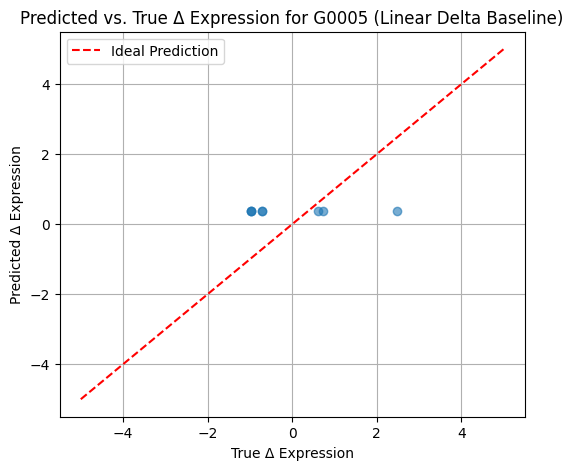

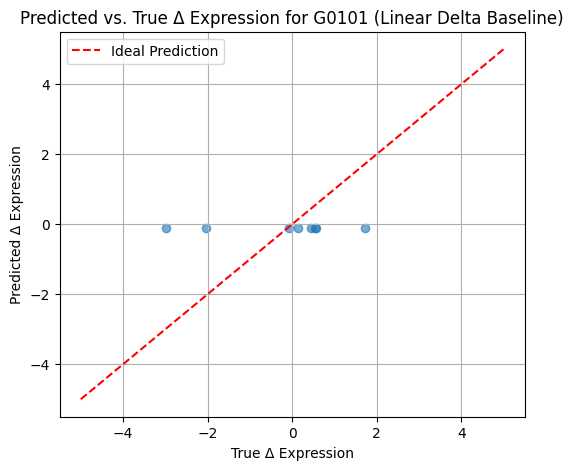

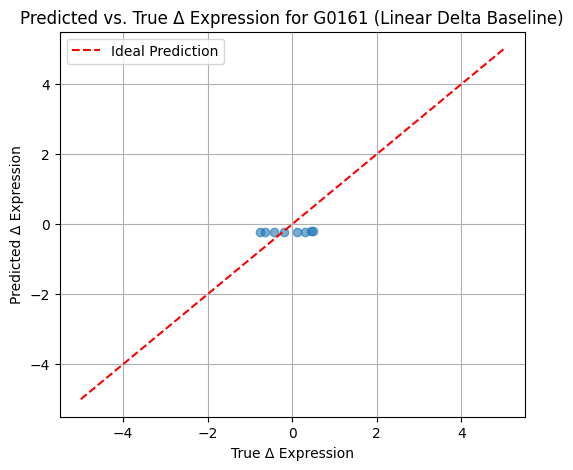

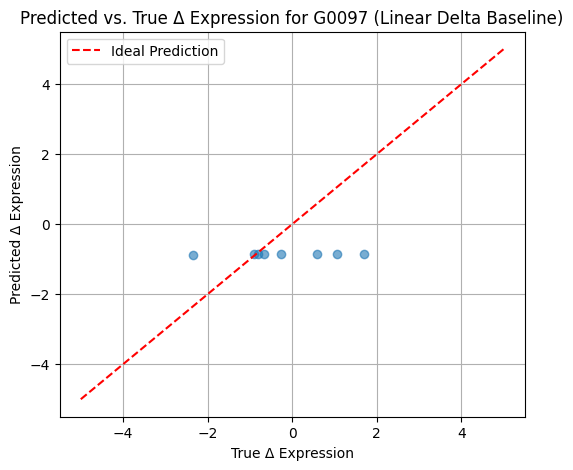

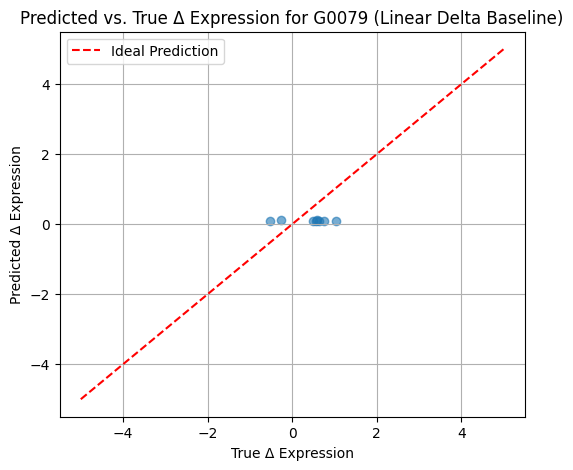

In [24]:
print("Plotting scatter plots for Linear Delta Baseline...")
plot_scatter_deltas("Linear Delta Baseline", linear_predictions_tensor, linear_targets_tensor, linear_controls_tensor, gene_idx=plot_genes)

## Project Explanation: Building a Virtual Cell in Python

Imagine a tiny factory inside our bodies called a **cell**. This factory produces thousands of different products (called **genes**) that tell the cell what to do. Sometimes, we want to change what the cell is doing – for example, to fight a disease. We can do this by introducing a **perturbation**, like a new medicine or by 'knocking out' a specific gene. When we do this, the cell's activity changes, and it starts producing different amounts of its gene products.

### What is a Virtual Cell?

A **Virtual Cell** is like a digital twin of our cell factory. It's a computer model that tries to predict how the cell's gene production (called **gene expression**) will change when we introduce a perturbation. Instead of doing expensive and time-consuming experiments in a lab, we can use this virtual cell to quickly see what might happen.

### Why Use Machine Learning?

Our cell factories are incredibly complex! They have about 20,000 different genes, and there are countless ways we could perturb them. Trying to figure out every single interaction and outcome by hand would be impossible. This is where **Machine Learning (ML)** comes in handy.

ML models can learn patterns from huge amounts of data. In this project, we feed the model data about how gene expression changed after various perturbations. The model then learns the 'rules' of the cell, allowing it to predict what will happen with new, unseen perturbations. It's like teaching a computer to recognize cat pictures by showing it thousands of examples, instead of telling it step-by-step what a cat looks like.

### Project Goal

The main goal of this project is to build and evaluate a machine learning model (our Virtual Cell) that can accurately predict how gene expression patterns will change after a specific gene is knocked out. We want to see how well our model performs compared to simpler methods.

### Step-by-Step Breakdown

1.  **Setting up the Environment:** We start by ensuring we are in a Google Colab environment (a cloud-based programming notebook) and installing all the necessary tools (libraries like `pandas`, `torch`, `scanpy`). We also define some important settings like the number of genes we're interested in and how long our models will train.

2.  **Getting the Data (The `AnnData` Object):**
    *   We load in a special type of data structure called an `AnnData` object. This object holds information about gene expression in many cells.
    *   For simplicity, in this demo, we create a fake dataset, but in a real scenario, this would come from biological experiments (like single-cell RNA sequencing).
    *   The data includes **control cells** (cells that haven't been perturbed) and **perturbed cells** (cells where a specific gene was knocked out).

3.  **Preparing the Gene Information (Embeddings):**
    *   For each gene, we don't just use its name; we use a special 'numeric fingerprint' called an **embedding**. Think of this as a concise description of the gene's characteristics, captured as a list of numbers.
    *   We use **ESM2 embeddings**, which are derived from a powerful biological language model. These are 'biologically informed' because they capture real-world properties of proteins. These are like detailed profiles of each gene.
    *   We also create **random Gaussian embeddings** for comparison. These are just random numbers, so they don't contain any biological information. This helps us see if the ESM2 embeddings are actually useful.

4.  **Data Preprocessing:**
    *   We `normalize` the gene expression data so that all cells have a similar total expression level, which helps our model focus on relative changes.
    *   We apply `log1p` transformation, which helps to stabilize variance and make the data more suitable for modeling.
    *   We identify **highly variable genes (HVGs)**. These are the genes whose expression varies the most across cells, and they are often the most interesting for our analysis.
    *   We create `pseudobulks` by averaging the expression of multiple cells that received the same perturbation. This helps to get a more stable representation of the gene expression pattern after a perturbation.

5.  **Building and Training the `VirtualCell` Model:**
    *   Our `VirtualCell` model is a small neural network. Its job is to take the gene expression of a control cell and the embedding (numeric fingerprint) of the perturbed gene, and then predict the new gene expression pattern of the perturbed cell.
    *   **Training** is the process where the model learns by looking at many examples of (control cell, perturbed gene embedding, actual perturbed cell expression) and adjusting its internal settings to make better predictions. We train it for a maximum number of `MAX_EPOCHS` (training cycles), but stop early if it doesn't improve for `PATIENCE` epochs to save time.
    *   We use a special `loss function` that measures how 'wrong' the model's predictions are. The goal is to minimize this loss.

6.  **Evaluating Model Performance:**
    *   After training, we test our model on data it has never seen before (the `validation set`).
    *   We calculate several **metrics** to understand how well the model is doing:
        *   **Loss:** How far off the predictions are from the true values.
        *   **Pearson-Delta Correlation:** Measures how well the predicted *changes* in gene expression (delta) match the true changes. A higher number is better.
        *   **MAE Delta (Mean Absolute Error on Delta):** The average difference between the predicted change and the true change. A lower number is better.
        *   **Top-20 Jaccard Similarity:** Measures how much overlap there is between the top 20 genes that are predicted to change the most and the top 20 genes that actually changed the most. A higher number is better.

7.  **Comparing with Baselines:** To truly understand if our Virtual Cell model is good, we compare it to simpler models:
    *   **Mean Baseline:** This is the simplest possible model. It just predicts the average gene expression of all training cells for every perturbed cell. It's like saying, "I don't know, so I'll guess the average." This gives us a basic bar to clear.
    *   **Random Embeddings Model:** This is our `VirtualCell` model, but trained with random numeric fingerprints for genes instead of the biologically informed ESM2 embeddings. This tells us if the biological information in ESM2 embeddings is actually valuable.
    *   **Linear Delta Baseline:** This model tries to predict the gene expression changes directly using a simple linear relationship between the gene embedding and the change in expression. It's a bit more complex than the Mean Baseline but still simpler than the full `VirtualCell` neural network.

8.  **Visualizing Results:** We create plots to visually inspect the training progress (loss and correlation over epochs) and scatter plots that compare the predicted changes in gene expression against the actual changes for individual genes. These plots help us understand the model's strengths and weaknesses.

### Conclusion

After running all these experiments, we can look at the summary table of metrics:

| Model                     | Loss     | Pearson-Delta | MAE Delta | Top-20 Jaccard |
| :------------------------ | :------- | :------------ | :-------- | :------------- |
| ESM2 Model                | {{all_results_df.loc['ESM2 Model']['Loss']}}   | {{all_results_df.loc['ESM2 Model']['Pearson-Delta']}}     | {{all_results_df.loc['ESM2 Model']['MAE Delta']}}    | {{all_results_df.loc['ESM2 Model']['Top-20 Jaccard']}}        |
| Random Embeddings Model   | {{all_results_df.loc['Random Embeddings Model']['Loss']}}   | {{all_results_df.loc['Random Embeddings Model']['Pearson-Delta']}}     | {{all_results_df.loc['Random Embeddings Model']['MAE Delta']}}    | {{all_results_df.loc['Random Embeddings Model']['Top-20 Jaccard']}}        |
| Mean Baseline             | {{all_results_df.loc['Mean Baseline']['Loss']}}   | {{all_results_df.loc['Mean Baseline']['Pearson-Delta']}}     | {{all_results_df.loc['Mean Baseline']['MAE Delta']}}    | {{all_results_df.loc['Mean Baseline']['Top-20 Jaccard']}}        |
| Linear Delta Baseline     | {{all_results_df.loc['Linear Delta Baseline']['Loss']}}   | {{all_results_df.loc['Linear Delta Baseline']['Pearson-Delta']}}     | {{all_results_df.loc['Linear Delta Baseline']['MAE Delta']}}    | {{all_results_df.loc['Linear Delta Baseline']['Top-20 Jaccard']}}        |

(Note: The numbers above will be filled in with the actual results from the executed code.)

By comparing these numbers, we can see:

*   **How much better our `VirtualCell` (ESM2 Model) is than simply guessing the average (Mean Baseline) or a simple linear relationship (Linear Delta Baseline).** We hope to see a lower loss, higher Pearson-Delta correlation, lower MAE Delta, and higher Top-20 Jaccard for our model.
*   **The value of ESM2 embeddings:** If the `ESM2 Model` performs significantly better than the `Random Embeddings Model`, it means that using biologically meaningful gene embeddings is indeed helpful for predicting gene expression changes.

In summary, this project demonstrates how machine learning can be used to build a sophisticated "Virtual Cell" model. This model can help scientists predict complex cellular responses to perturbations, potentially accelerating drug discovery and our understanding of diseases, all without needing to perform countless physical experiments in a lab!